In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.5
numpy 2.3.2
torch 2.8.0+cu128
cuda:0


## 数据加载

In [ ]:
import unicodedata  # 用于处理Unicode字符（如带重音字符），以便统一和简化字符集
import re           # 用于正则表达式操作，便于文本清洗

# 许多西班牙语单词包含特殊字符或重音字母
# 通过将Unicode字符转换为ASCII，可以减少字符集复杂度，便于后续处理
def unicode_to_ascii(s):
    """
    将Unicode字符串s转换为纯ASCII字符串。
    实现步骤为：先采用NFD方式将字符分解（如á被分成a和´），
    然后去除所有类别为Mn（非间距标记，通常是重音符号）的字符，
    最终仅保留ASCII字符。

    参数:
        s (str): 输入的Unicode字符串
    返回:
        str: 处理后的ASCII字符串
    """
    # NFD分解后，仅保留类别不是Mn（重音符等）的字符
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# 测试该函数：分别用英文和含有重音符号、特殊符号的西班牙语句子
# u前缀在python3中已默认字符串为unicode，可省略，但为兼容性保留
en_sentence = u"May I borrow this book?"           # 英文示例句
sp_sentence = u"¿Puedo tomar prestado este libro?" # 西班牙语句，包括倒问号

# 输出ASCII转换效果
print(unicode_to_ascii(en_sentence))    # 期望: May I borrow this book?
print(unicode_to_ascii(sp_sentence))    # 期望: ?Puedo tomar prestado este libro?


May I borrow this book?
¿Puedo tomar prestado este libro?


In [5]:
def preprocess_sentence(w):
    """
    对输入的句子w进行标准化和清洗处理，步骤如下：
    1. 全部转换为小写，并去除前后多余的空格。
    2. 将Unicode字符转换为ASCII，去除重音等特殊符号，统一西班牙语等特殊字符集。
    3. 在每个标点符号（. ? ! , ¿）两侧加上空格，避免标点和单词黏连，方便后续分词。
    4. 将除英文字母(a-z, A-Z)和指定标点符号（. ? ! , ¿）之外的所有字符替换为一个空格，过滤无用字符。
    5. 多个连续的空格合并为一个空格，保证干净整齐的文本格式。
    6. 再次去除首尾空格，确保句首和句尾没有多余空格。
    :param w: 输入的原始句子（字符串）
    :return: 经过上述清洗和格式化处理的新句子（字符串）
    """
    # 步骤1和2：变为全小写并去除首尾空格，同时转换为ASCII码，即去掉所有重音和修饰符
    w = unicode_to_ascii(w.lower().strip())

    # 步骤3：在每个指定标点（. ? ! , ¿）两侧加上空格，方便后续分词
    # 例如："hello." -> "hello . "
    # 这里\1为分组（即匹配到的标点）本身，r" \1 "表示在前后加空格
    w = re.sub(r"([?.!,¿])", r" \1 ", w)

    # 步骤4：用空格替换所有英文字母及指定标点以外的字符（比如数字、@、#等都变为空格）
    # 只保留字母a-zA-Z及. ? ! , ¿
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

    # 步骤5：将多个连续空格合并成一个空格，防止因为上面替换操作形成一堆空格
    w = re.sub(r'[" "]+', " ", w)

    # 步骤6：再去首尾空格，避免残留空白
    w = w.rstrip().strip()

    return w

# 打印英文句子的处理结果
print(preprocess_sentence(en_sentence))
# 打印西班牙语句子的处理结果
print(preprocess_sentence(sp_sentence))
# 打印西班牙语句子的处理结果（utf-8编码后，'¿'为两个字节）
print(preprocess_sentence(sp_sentence).encode('utf-8'))  #¿是占用两个字节的

may i borrow this book ?
¿ puedo tomar prestado este libro ?
b'\xc2\xbf puedo tomar prestado este libro ?'


Dataset

In [6]:
#zip例子
a = [[1,2],[4,5],[7,8]]
sample,label = zip(*a)
print(sample)
print(label)

(1, 4, 7)
(2, 5, 8)


In [7]:
# 使用np.random.choice生成一个长度为100的数组split_index1，对每个样本随机赋予"train"或"test"标签
# a参数指定可选元素为"train"和"test"
# replace=True表示可重复抽取，即每个样本都可被标记为"train"或"test"
# p=[0.9, 0.1]表示90%的概率标记为"train"，10%的概率为"test"
# size=100表示一共生成100个标签
split_index1 = np.random.choice(a=["train", "test"], replace=True, p=[0.9, 0.1], size=100)
# 输出生成的训练/测试标签数组，可用于数据集划分查看
split_index1

array(['train', 'test', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'test', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'test', 'test',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'test', 'train', 'train', 'train', 'train', 'train',
       'train', 'test', 'train', 'test', 'train', 'train', 'test',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'test',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train'], dty

In [8]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

class LangPairDataset(Dataset):
    # 原始数据集的文件路径
    fpath = Path(r"./data_spa_en/spa.txt")  # 数据文件路径
    # 预处理后缓存的路径，避免每次都重新处理原始数据
    # 缓存的作用是加速数据加载，避免每次实例化数据集都重新处理原始文本。
    # 第一次运行时，原始 spa.txt 文件会被分词、清洗，然后以 numpy 数组形式存储到 cache_path 指定的.npy文件中，
    # 以后只需加载缓存文件，无需再读取和预处理原始文本，大幅提升效率，尤其是多次实验时非常有用。
    cache_path = Path(r"./.cache/lang_pair.npy")  # 缓存文件路径
    # 生成一个长度等于语料数据行数的分割索引，9:1概率产生'train'或'test'标签
    # 这里的split_index是一个 shape=(数据集样本数,) 的一维 numpy 数组，每个元素是字符串 "train" 或 "test"，长度与原始数据集的行数（样本数）相同。
    # 例如: array(['train', 'train', 'test', 'train', ..., 'test'], dtype='<U5')
    # 每一行（样本）通过等概率（如p=[0.9,0.1]）标签，决定属于训练集还是测试集。
    split_index = np.random.choice(
        a=["train", "test"],  # 可选标签，train/test
        replace=True,         # 可以有重复
        p=[0.9, 0.1],         # 90%为train，10%为test
        size=118964           # 数据量大小。此处需与原数据集样本行数一致
    )
    def __init__(self, mode="train", cache=False):
        """
        初始化数据集对象。

        参数:
        mode: 'train' 或 'test'，用于指明构造的是什么子集。
        cache: 是否强制重新生成缓存（True时无视已有缓存）。
        """
        if cache or not self.cache_path.exists():
            # 如果指定cache或缓存文件不存在，则需直接读取原始文本文件并处理
            # 这里主要完成：从原始文本文件读取，每一行按`\t`分隔成[源, 目标]对，然后对每个分句进行预处理。
            # 处理结束后用numpy保存字典{"trg": trg（目标语言数组）, "src": src（源语言数组）}到缓存npy文件
            # 1. self.cache_path.parent.mkdir(parents=True, exist_ok=True)：创建缓存文件夹
            # 2. open(self.fpath, ...) as file: 打开原始数据文件（spa.txt）
            # 3. lines = file.readlines()：读取所有行，每行含 源语言句子 和 目标语言句子，用'\t'隔开
            # 4. lang_pair = [[preprocess_sentence(w) for w in l.split('\t')] for l in lines]
            #    - 遍历每一行l，split('\t')分成2部分，对每部分调用preprocess_sentence
            #    - 最终lang_pair变成二维列表：[[trg1, src1], [trg2, src2], ...]
            # 5. trg, src = zip(*lang_pair)：解包二维列表，得到所有目标和源组成的两个元组
            # 6. trg=np.array(trg)，src=np.array(src)：转为numpy数组
            # 7. np.save(self.cache_path, {"trg": trg, "src": src})：以dict方式保存为npy文件
            
            # 创建缓存文件夹，如果其父目录不存在则递归创建（parents=True），已存在时不会报错（exist_ok=True）
            self.cache_path.parent.mkdir(parents=True, exist_ok=True)
            with open(self.fpath, "r", encoding="utf8") as file:
                lines = file.readlines()  # 逐行读取原始语料
                # 对每一行，通过split('\t')获得[目标语句, 源语句]，并用 preprocess_sentence 进行清洗
                # lang_pair 是形如 [[trg1, src1], [trg2, src2], ...] 的二维列表

                # 是的，这里的 w 只会被赋值为每一行用 \t 分割得到的两个字符串之一（目标句和源句），不是单词。
                # 例如 line = "Go.\tVe.\n"，l.split('\t') 得到 ["Go.", "Ve.\n"]，每个 w 就是完整的句子。
                # preprocess_sentence(w) 预处理的是整个句子不是单词。
                lang_pair = [
                    [preprocess_sentence(w) for w in l.split('\t')]
                    for l in lines
                ]
                # 使用zip*解包，分离得到两个元组：trg（目标）和src（来源）
                trg, src = zip(*lang_pair)
                trg = np.array(trg)  # 转为numpy数组，便于后续索引和存储
                src = np.array(src)
                # 把两个数组序列化存为.npy，字典格式，提升处理效率
                print("缓存文件已保存：", self.cache_path)
                np.save(self.cache_path, {"trg": trg, "src": src})
        else:
            # 走缓存（npy），直接读取
            # 这里走npy缓存，直接读出来的数据类型是dict，dict里'trg'和'src'是两个np.ndarray（字符串数组）
            # lang_pair变量其实是dict，然后 trg/src 是 ndarray
            # 举例: lang_pair = {'trg': np.ndarray, 'src': np.ndarray}
            lang_pair = np.load(self.cache_path, allow_pickle=True).item()
            trg = lang_pair["trg"]
            src = lang_pair["src"]

        # 按预先随机划分的 split_index 选出属于 mode 的部分
        # split_index: shape=(总样本数,)，每一行为'train'或'test'，等长于src/trg
        # 这里self.trg和self.src都是按mode选的同一子集
        self.trg = trg[self.split_index == mode]   # 目标语言（英语）
        self.src = src[self.split_index == mode]   # 源语言（西班牙语）

    def __getitem__(self, index):
        """
        获取指定下标处的(source, target)语言样本。
        """
        return self.src[index], self.trg[index]

    def __len__(self):
        """
        返回数据集中样本数量（即源语言序列的数量）。
        """
        return len(self.src)  # 或len(self.trg)，二者长度应一致


# 创建训练集与测试集对象
train_ds = LangPairDataset("train")
test_ds = LangPairDataset("test")

In [9]:
print("source: {}\ntarget: {}".format(*train_ds[-1]))

source: si quieres sonar como un hablante nativo , debes estar dispuesto a practicar diciendo la misma frase una y otra vez de la misma manera en que un musico de banjo practica el mismo fraseo una y otra vez hasta que lo puedan tocar correctamente y en el tiempo esperado .
target: if you want to sound like a native speaker , you must be willing to practice saying the same sentence over and over in the same way that banjo players practice the same phrase over and over until they can play it correctly and at the desired tempo .


In [10]:
for pair in train_ds:
    print(pair[0])
    print(pair[1])
    break

ve .
go .


### Tokenizer

这里有两种处理方式，分别对应着 encoder 和 decoder 的 word embedding 是否共享，这里实现不共享的方案。

In [11]:
# 两本词典是指分别针对源语言（src）和目标语言（trg）分别构建的词到索引（word2idx）和索引到词（idx2word）字典。
# 这是因为在序列到序列（Seq2Seq）任务中，通常输入（encoder部分）和输出（decoder部分）是不同的语言，它们的词表不相同，词的索引分配也互不干扰。
# 这样可确保每种语言的分词、Embedding、预测解码等过程都是独立、不会混淆的。
# 所以需要“各自一套字典”，也就是“两本词典”。


from collections import Counter

def get_word_idx(ds, mode="src", threshold=2):
    """
    构建词表（word2idx/idx2word）的方法。

    参数:
    ds (Dataset): 传入的数据集（通常为训练集）。
    mode (str): "src" 表示源语言，"trg" 表示目标语言，决定从数据集中取第几个字段。
    threshold (int): 词频阈值，出现次数低于该值的 token 不会被加入词表。（实际中立即被覆盖为1）

    返回:
    word2idx (dict): token 到索引的映射。
    idx2word (dict): 索引到 token 的映射。
    """

    # 预设特殊 token，并分配索引：
    word2idx = {
        "[PAD]": 0,     # 填充 token（Padding token），用于补齐序列长度
        "[BOS]": 1,     # 句子开始 token（Begin of sentence）
        "[UNK]": 2,     # 未知 token（Unknown token），词表外词
        "[EOS]": 3,     # 句子结束 token（End of sentence）
    }
    # 反向索引表，索引到token
    idx2word = {value: key for key, value in word2idx.items()}
    index = len(idx2word)  # 下一个可用索引

    threshold = 1  # 保险起见将阈值设置为1（只丢弃出现频率为0的token）

    # 将数据集对应语言的全部句子拼接为一个词字符串，然后按空格切分为词列表
    # mode=="src"时取每个pair的第一个元素（源语言），否则为目标语言
    
    # 这一行代码作用是：将数据集 ds 中指定语言（src 或 trg）的所有句子合并成一个大的字符串，然后以空格为分隔符切分成词（token）列表。
    # 具体解释如下：
    # [pair[0 if mode == "src" else 1] for pair in ds]：遍历数据集 ds 的每个样本对 pair，
    #   如果 mode 为 "src" 就取第一个元素（源语言句子），否则取第二个元素（目标语言句子）。
    # 用 " ".join(...) 将所有句子连接成一串大文本，句子间加空格。
    # 最后用 .split() 以空格为界切分，得到所有词组成的列表 word_list。
    word_list = " ".join([pair[0 if mode == "src" else 1] for pair in ds]).split()

    # 统计词频：Counter返回的是一个字典，键是单词，值是出现次数
    # 会自动去重。Counter(word_list) 本身就统计了每个词出现的次数，counter的每个key只出现一次。
    counter = Counter(word_list)
    print("word count:", len(counter))  # 打印出去重后词的总数

    # 遍历所有词，根据出现次数决定是否加入词表
    for token, count in counter.items():
        if count >= threshold:   # 出现大于等于阈值的词才进入词表
            word2idx[token] = index   # 分配索引
            idx2word[index] = token   # 索引反查
            index += 1                # 下一个可用索引

    return word2idx, idx2word

# 构建源语言（西班牙语）词表。word2idx: {词:编号}，idx2word: {编号:词}
src_word2idx, src_idx2word = get_word_idx(train_ds, "src")  # 源语言词表
# 构建目标语言（英语）词表
trg_word2idx, trg_idx2word = get_word_idx(train_ds, "trg")  # 目标语言词表

word count: 23715
word count: 12500


In [12]:
trg_idx2word[5]

'.'

In [ ]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        初始化Tokenizer对象

        参数:
            word2idx (dict): 单词到索引的映射字典。
            idx2word (dict): 索引到单词的映射字典。
            max_length (int): 最大句子长度，超过会被截断（加上BOS/EOS）。
            pad_idx (int): Padding标记的索引。
            bos_idx (int): 句子开始符号的索引。
            eos_idx (int): 句子结束符号的索引。
            unk_idx (int): 未知词的索引。
        """
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """
        将分词后的句子批量编码为索引，并进行padding，支持前/后补齐。
        
        参数:
            text_list (list[list[str]]): 句子分词后的列表，每个元素是一个分词列表。
            padding_first (bool): 是否前向padding（True: pad加在左边，False: 右边）。
            add_bos (bool): 是否在每句前添加BOS标记。
            add_eos (bool): 是否在每句后添加EOS标记。
            return_mask (bool): 是否返回mask（1代表pad，0代表有效token）。
        返回:
            input_ids: shape=[batch, seq_len]的tensor，每个token为其索引。
            masks: (可选) shape与input_ids相同，pad位置为1，其余为0。
        """
        # 动态计算本批次最大长度，不超过self.max_length
        max_length = min(
            self.max_length,
            add_eos + add_bos + max([len(text) for text in text_list])
        )
        indices_list = []
        for text in text_list:
            # 先截取最大长度（考虑BOS/EOS的占位），映射为索引，词表外用unk替代
            indices = [self.word2idx.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]]
            if add_bos:
                indices = [self.bos_idx] + indices
            if add_eos:
                indices = indices + [self.eos_idx]
            # 根据padding_first参数确定pad方式（前/后补0至指定长度）
            if padding_first:
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        input_ids = torch.tensor(indices_list)
        # 生成mask：pad为1，其余为0，掩码常用于后续损失与attention的mask
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)
        return input_ids if not return_mask else (input_ids, masks)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        将索引序列反解为文本（单句或批量），可选去除特殊标记
        
        参数:
            indices_list (list[list[int]]): 每个句子的索引序列（支持tensor或list）
            remove_bos (bool): 是否去掉[BOS]
            remove_eos (bool): 是否遇到[EOS]后即终止
            remove_pad (bool): 是否遇到[PAD]后即终止
            split (bool): True返回分词list，False返回拼接的字符串句子
        返回:
            text_list: 解码后字符串/分词数组列表
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]")
                if remove_bos and word == "[BOS]":
                    continue  # 跳过BOS
                if remove_eos and word == "[EOS]":
                    break     # 碰到EOS则立即终止（常见于预测解码节点）
                if remove_pad and word == "[PAD]":
                    break     # PAD终止（只留真实内容）
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list

# 注：分别为源语言和目标语言建立Tokenizer可减少各自Embedding参数量
src_tokenizer = Tokenizer(word2idx=src_word2idx, idx2word=src_idx2word)  # 源语言Tokenizer
trg_tokenizer = Tokenizer(word2idx=trg_word2idx, idx2word=trg_idx2word)  # 目标语言Tokenizer

# 构造一批dummy数据，测试编码器和mask生成
raw_text = [
    "hello world".split(),
    "tokenize text datas with batch".split(),
    "this is a test".split()
]

# 对raw_text进行编码，右侧补pad，添加BOS/EOS，并返回mask
indices, mask = trg_tokenizer.encode(
    raw_text, 
    padding_first=False,   # pad后填
    add_bos=True, 
    add_eos=True, 
    return_mask=True
)

print("raw text" + '-' * 10)
for raw in raw_text:
    print(raw)
print("mask" + '-' * 10)
for m in mask:
    print(m)
print("indices" + '-' * 10)
for index in indices:
    print(index)


raw text----------
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']
mask----------
tensor([0, 0, 0, 0, 1, 1, 1])
tensor([0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0, 0, 1])
indices----------
tensor([   1,   16, 3218,    3,    0,    0,    0])
tensor([   1,    2, 3878,    2,  552,    2,    3])
tensor([   1,  117,  235,  103, 2896,    3,    0])


In [14]:
decode_text = trg_tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)
print("decode text"+'-'*10)
for decode in decode_text:
    print(decode)

decode text----------
[BOS] hello world [EOS] [PAD] [PAD] [PAD]
[BOS] [UNK] text [UNK] with [UNK] [EOS]
[BOS] this is a test [EOS] [PAD]


### DataLoader

In [ ]:
def collate_fct(batch):
    """
    自定义的批处理（collate）函数，用于DataLoader。
    处理流程:
        - 将batch（一批样本）中的文本内容分成words列表（分词）
        - 编码源语言（src）和目标语言（trg）的句子，添加特殊token（BOS/EOS/PAD），并生成mask
        - 返回包含多项tensor格式结果的字典
    参数:
        batch: List[Tuple[str, str]]
            比如：[(src_sentence1, trg_sentence1), (src_sentence2, trg_sentence2), ...]
    返回:
        一个包含模型输入所需各项的字典
    """

    # 取batch内第0列（源语言句子），对每句进行split分词，得到二维列表
    src_words = [pair[0].split() for pair in batch]  
    # 取batch内第1列（目标语言句子），对每句进行split分词，得到二维列表
    trg_words = [pair[1].split() for pair in batch]  

    # mask用于指示padding的位置，使模型忽略这些填充的部分。一般原则如下：
    # 1. 对encoder输入（源语言句子），需要mask，因为实际输入序列中存在padding。
    #    在self-attention/encoder-decoder attention中，mask可以屏蔽掉PAD token的影响。
    # 2. 对decoder输出标签（也就是ground truth），需要对应的mask，便于计算loss时忽略PAD部分，避免padding影响loss计算。
    # 3. 对decoder的输入（teacher-forcing的目标输入），通常不需要mask，因为解码器生成时主要依赖于输入序列本身，不需要额外对padding位置特殊处理。
    # 总结：凡是会有padding且需要屏蔽padding影响（如encoder输入、loss计算标签），就要加mask；单纯作为解码器输入feeding时可不加mask。

    # 为什么采取这种不同的填充策略
    # 
    # 1. 对encoder输入（源语言），采用的是左侧padding（padding_first=True），主要原因在于部分模型（如Transformer等）对填充位置并不敏感，但左pad更方便做mask以及适配部分旧序列模型（如某些RNN）。
    #
    # 2. 对decoder输入/输出（目标语言）通常采用右侧padding（padding_first=False），这样在自回归生成时，实际target输出的有效内容总是排列在左边，后面的padding不会干扰预测，有利于训练时候mask的处理和解码规约。
    #
    # 3. decoder输入和decoder输出虽然都右pad，但训练decoder的时候通常decoder_input前加BOS，decoder_label后加EOS，这样对齐方式是：
    #    decoder_inputs: <BOS> w1 w2 w3 <PAD> <PAD>
    #    decoder_labels: w1    w2 w3 <EOS> <PAD> <PAD>
    #    这样一一对应，实现teacher forcing。 
    #
    # 总体目的：合理设计padding和特殊token的顺序与位置，能确保loss、mask处理逻辑高效且推理时无歧义。
    

    # encoder输入（源语言）一般在句首加BOS，在句末加EOS，这样做的目的是：
    #   1. BOS可以让模型更明确地标记每个输入序列的起始，有助于模型捕捉序列开始时的重要上下文。
    #   2. EOS用于指示输入序列的终止，让模型知道何时停止关注后续内容，提升对句子边界的感知能力。
    #   3. 对序列建模（比如 RNN/Transformer）来说，明确的序列起止标记能帮助模型区分不同句子间的内容，减少截断或拼接时的信息混淆。
    # 如果缺了BOS/EOS，模型在处理接续多个输入时可能丢失句子边界的信息，不利于正确抽取特征或生成对齐的表示。
    
    # 那BOS，EOS的添加为何不同，为什么要这样设计呢
    # 
    # 1. 在encoder输入（源语言）上，通常在句首加BOS、句尾加EOS，以便模型明确定义序列边界，有助于捕捉上下文边界信息。
    #    这样做也方便与decoder的对齐处理（尤其是在做alignment或copy机制等）。BOS/EOS都加，无歧义。
    #
    # 2. 对decoder输入（teacher forcing时的目标输入），我们只在句首加BOS，不加EOS。
    #    这样做的原因：decoder在生成第t个词时，需要看到前t-1个目标词（即<bos> w1 w2 ...），这样预测下一个词w_t。
    #    不加EOS可以保证decoder输入和输出严格对齐（shift一位）。
    #
    # 3. 对decoder输出（即训练标签），不加BOS，句尾加EOS。
    #    这样设计原因是：让模型显式学会在句子末尾输出<EOS>，而标签不需要BOS。
    #    换句话说，decoder输入和输出在时间轴上是错开一位的，保证每步decoder输入和预测的输出严格对应并可对齐，
    #    这样teacher forcing和mask的处理才方便。
    #
    # 总结：
    #   encoder_inputs: <BOS> w1 w2 ... wn <EOS>
    #   decoder_inputs: <BOS> y1 y2 ... ym
    #   decoder_labels:      y1 y2 ... ym <EOS>
    #   每一位置的数据相互shift一位，使模型能学会正确生成起始和终止标记，并且方便计算loss。

    # dataloader每次会输出一个batch（比如batch_size=3），每个batch是 ["i am tom .", "hi !", "good night ."]
    # 假设src_tokenizer的BOS是<sos> (id=1)，EOS是<eos> (id=2)，PAD是<pad> (id=0)。
    # 以encoder输入为例：我们对每个句子前加BOS、后加EOS，pad到最长长度+2（多了BOS、EOS），左pad，比如:
    # 1. 原batch:         ["i am tom .",      "hi !",        "good night ."]
    # 2. 分词后:          [["i", "am", "tom", "."], ["hi", "!"], ["good", "night", "."]]
    # 3. 加BOS/EOS:       [["<sos>","i","am","tom",".","<eos>"],
    #                      ["<sos>","hi","!","<eos>"],
    #                      ["<sos>","good","night",".","<eos>"]]
    # 4. 找最长长度（6），左pad，不足的在前面补<pad>（假设id=0）:
    #    [
    #      ['<sos>','i','am','tom','.','<eos>'],         # 长度6，不用pad
    #      ['<pad>','<pad>','<sos>','hi','!','<eos>'],   # pad2
    #      ['<pad>','<sos>','good','night','.','<eos>']  # pad1
    #    ]
    # tokenizer.encode后就是整数id组成的batch，例如:
    #    [
    #      [1,  5,  8, 14,  3, 2],
    #      [0,  0,  1, 16, 18, 2],
    #      [0,  1, 22,  6,  3, 2]
    #    ]
    # 这样就算分batch，每句都有清晰的起始(<sos>)和终止(<eos>)标记，模型看到每个句子的边界信息，不会把pad当有效内容处理。

    # 对源语言（encoder输入）编码:
    #  - 在前面加BOS，后面加EOS
    #  - pad补齐到同一长度，pad在序列左侧（padding_first=True）
    encoder_inputs, encoder_inputs_mask = src_tokenizer.encode(
        src_words, 
        padding_first=True,   # pad在前
        add_bos=True,        # 增加BOS
        add_eos=True,        # 增加EOS
        return_mask=True     # 返回padding mask
    )

    # 对目标语言（decoder输入）编码:
    #  - 在前面加BOS，不加EOS
    #  - pad补齐到同一长度，pad在序列右侧（padding_first=False）
    #  - 不需要mask
    decoder_inputs = trg_tokenizer.encode(
        trg_words, 
        padding_first=False,  # pad在后
        add_bos=True,         # 增加BOS
        add_eos=False,        # 不加EOS
        return_mask=False     # 不返回mask
    )

    # 对目标语言（decoder输出标签）编码:
    #  - 不加BOS，在结尾加EOS
    #  - pad补齐到同一长度，pad在序列右侧（padding_first=False）
    #  - 需要mask
    decoder_labels, decoder_labels_mask = trg_tokenizer.encode(
        trg_words, 
        padding_first=False,  # pad在后
        add_bos=False,        # 不加BOS
        add_eos=True,         # 增加EOS
        return_mask=True      # 返回mask
    )

    # 返回dict字典，包含所有模型训练和推理所需的输入
    return {
        # encoder输入的句子序列（带token id）
        "encoder_inputs": encoder_inputs.to(device=device),
        # encoder输入对应的padding mask
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),
        # decoder输入序列（带token id），用于训练teacher-forcing
        "decoder_inputs": decoder_inputs.to(device=device),
        # decoder输出标签序列（带token id），用于计算loss
        "decoder_labels": decoder_labels.to(device=device),
        # decoder输出标签对应的有效mask，mask用于去除padding对loss的影响
        "decoder_labels_mask": decoder_labels_mask.to(device=device), 
    }


In [16]:
# 本代码块演示如何基于上面定义的collate_fct对train_ds中的样本进行批量数据准备和封装处理，并详细输出每个字段含义和shape。
# collate_fct会自动对一批（这里batch_size=2）样本，将原始句子分别编码为适合模型输入的张量，包括padding、加BOS/EOS等，并组合为字典。

sample_dl = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fct)

# 每次循环取一批数据（batch），collate_fct会负责把原始样本打包（编码、补pad、mask等），
# 每个batch为一个dict，包含模型训练和推理需要的5个字段：
#  "encoder_inputs", "encoder_inputs_mask", "decoder_inputs", "decoder_labels", "decoder_labels_mask"

# 由于DataLoader设置了shuffle=True，每次执行得到的内容可能不一样（样本顺序不同）。
for batch in sample_dl:
    print("当前batch的全部字段及对应shape和内容如下（由collate_fct处理生成）：\n")
    for key, value in batch.items():
        print(f"{key}: 形状 {value.shape}")
        print(value)
        print("\n------\n")
    print("说明：")
    print("- encoder_inputs: 源语言token id序列，已添加BOS和EOS，并pad到统一长度，适用于Encoder输入。")
    print("- encoder_inputs_mask: encoder_inputs对应的pad位置mask（值为0是pad，1是有效token），方便忽略padding。")
    print("- decoder_inputs: 目标语言token id序列，已加BOS（无EOS），pad到统一长度，作为Decoder输入（Teacher Forcing）。")
    print("- decoder_labels: 目标语言token id序列（去掉BOS，加上EOS），pad到统一长度，作为Decoder的输出标签。")
    print("- decoder_labels_mask: decoder_labels的mask，用于loss时去除padding区域的影响。")
    break  # 只输出第一个batch示例

当前batch的全部字段及对应shape和内容如下（由collate_fct处理生成）：

encoder_inputs: 形状 torch.Size([2, 9])
tensor([[   0,    1,   55,   67, 1056,  306,   50,    5,    3],
        [   1,   92, 5604,   50, 2622,  489, 3758,    5,    3]],
       device='cuda:0')

------

encoder_inputs_mask: 形状 torch.Size([2, 9])
tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')

------

decoder_inputs: 形状 torch.Size([2, 9])
tensor([[   1,   17,   32,  516,   30, 1088, 1577,    5,    0],
        [   1,   47, 2976,  689, 5400, 2238,  634,   29,    5]],
       device='cuda:0')

------

decoder_labels: 形状 torch.Size([2, 9])
tensor([[  17,   32,  516,   30, 1088, 1577,    5,    3,    0],
        [  47, 2976,  689, 5400, 2238,  634,   29,    5,    3]],
       device='cuda:0')

------

decoder_labels_mask: 形状 torch.Size([2, 9])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')

------

说明：
- encoder_inputs: 源语言token id序列，已添加BOS和EOS，并pad到统一长度，适用于Encode

## 定义模型

In [ ]:
class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        """
        Encoder模块（多层GRU为编码器）:
            - vocab_size: 输入词表的大小（即有多少种token）
            - embedding_dim: 词嵌入维度，把输入token id映射为embedding向量
            - hidden_dim: GRU隐状态的维度（每一个GRU单元输出的向量长度）
            - num_layers: GRU堆叠的层数
        """
        super().__init__()
        # nn.Embedding层：将token id输入转换为embedding向量，shape: [batch, seq_len] → [batch, seq_len, embedding_dim]
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # GRU层：输入embedding序列，输出每个时间步的输出和最后时刻所有层的hidden状态
        # batch_first=True: 输入输出的第一个维度为batch
        self.gru = nn.GRU(
            embedding_dim,           # 每个token的Embedding向量长度
            hidden_dim,              # GRU隐状态输出的维度
            num_layers=num_layers,   # 堆叠GRU层数
            batch_first=True         # 输入形状为[batch, seq, feat]
        )

    def forward(self, encoder_inputs):
        """
        前向传播
        encoder_inputs: [batch size, sequence length]，每个元素为token id
            1. 先通过embedding层，将token id映射成向量
            2. 把embedding序列输入GRU
            3. 返回encoder所有step的输出序列，以及最后时刻所有层的hidden state
        返回:
            seq_output: 所有时间步的输出，形状 [batch size, sequence length, hidden_dim]
            hidden: 所有层最后时刻的hidden拼接，形状 [num_layers, batch size, hidden_dim]
        """
        # 1. 将token id转为embedding向量, [batch, seq_len] -> [batch, seq_len, embedding_dim]
        embeds = self.embedding(encoder_inputs)

        # 2. 输入GRU, 获得每个时间步的输出和最后所有层的hidden
        seq_output, hidden = self.gru(embeds)
        # seq_output: 最后一层GRU每个时间步的输出, 形状 [batch size, sequence length, hidden_dim]
        # hidden: 所有层最后时刻的hidden状态, 形状 [num_layers, batch size, hidden_dim]
        return seq_output, hidden

In [18]:
#把上面的Encoder写一个例子，看看输出的shape
encoder = Encoder(vocab_size=100, embedding_dim=256, hidden_dim=1024, num_layers=4)
encoder_inputs = torch.randint(0, 100, (2, 50))
encoder_outputs, hidden = encoder(encoder_inputs)
print(encoder_outputs.shape)
print(hidden.shape)
print(encoder_outputs[:,-1,:])
print(hidden[-1,:,:]) #取最后一层的hidden

torch.Size([2, 50, 1024])
torch.Size([4, 2, 1024])
tensor([[-0.0636,  0.0092,  0.0103,  ..., -0.0153, -0.0004, -0.0341],
        [-0.0175,  0.0283,  0.0105,  ...,  0.0142,  0.0282, -0.0413]],
       grad_fn=<SliceBackward0>)
tensor([[-0.0636,  0.0092,  0.0103,  ..., -0.0153, -0.0004, -0.0341],
        [-0.0175,  0.0283,  0.0105,  ...,  0.0142,  0.0282, -0.0413]],
       grad_fn=<SliceBackward0>)


In [19]:
query1 = torch.randn(2, 1024)
query1.unsqueeze(1).shape #增加维度

torch.Size([2, 1, 1024])

## BahdanauAttention公式
score = FC(tanh(FC(EO) + FC(H))) #FC(EO)的FC是Wk,FC(H)的FC是Wq,最外面的FC是V 

attention_weights = softmax(score, axis = 1)  

context = sum(attention_weights * EO, axis = 1) #对EO做加权求和，得到上下文向量

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim=1024):
        super().__init__()
        self.Wk = nn.Linear(hidden_dim, hidden_dim) # 对 encoder 的输出（keys）做线性变换
        self.Wq = nn.Linear(hidden_dim, hidden_dim) # 对 decoder 隐状态（query）做线性变换
        self.V = nn.Linear(hidden_dim, 1)           # 再加权变成得分

    def forward(self, query, keys, values, attn_mask=None):
        """
        前向传播
        :param query: decoder当前时刻的隐藏状态，形状 [batch size, hidden_dim]
        :param keys: 编码器输出（encoder outputs），形状 [batch size, sequence length, hidden_dim]
        :param values: 一般同keys，形状 [batch size, sequence length, hidden_dim]
        :param attn_mask: 掩码张量，形状 [batch size, sequence length]，1表示PAD（需要mask），0表示有效token
        :return: context_vector [batch size, hidden_dim], attention_weights [batch size, sequence length, 1]
        """
        # query: [batch size, hidden_dim] -> [batch size, 1, hidden_dim]，以便和 keys 做逐步相加（广播机制）
        # keys: [batch size, sequence length, hidden_dim]
        # values: [batch size, sequence length, hidden_dim]

        # 把 query 扩展一个维度，shape 变成 [batch size, 1, hidden_dim]，用于后续广播加法
        # self.Wk(keys): 不变，输出 [batch size, sequence length, hidden_dim]
        # self.Wq(query.unsqueeze(-2)): 先 [batch size, 1, hidden_dim]，再线性变换，得到 [batch size, 1, hidden_dim]
        # 广播相加后 shape 为 [batch size, sequence length, hidden_dim]
        # F.tanh 激活不变
        # self.V: 最后一维hidden_dim线性变为1，shape [batch size, sequence length, 1]
        scores = self.V(F.tanh(self.Wk(keys) + self.Wq(query.unsqueeze(-2)))) # 计算每个key对当前query的相关性分数

        # score形状是 [batch size, sequence length, 1]，每个时间步（单词）有一个分数

        # 如果有mask，则把mask==1的位置加上非常小的值（-1e16），softmax后，这些位置attention概率约等于0，达到屏蔽padding的效果
        # attn_mask: [batch size, sequence length], 1表示padding（要mask）、0表示有效
        # 先扩展到 [batch size, sequence length, 1]，再乘以-1e16并加到scores上
        if attn_mask is not None:
            attn_mask = (attn_mask.unsqueeze(-1)) * -1e16
            scores += attn_mask

        # 对每个词分数做softmax，dim=-2保证是在 sequence length 维度归一化概率，最后维度不变
        attention_weights = F.softmax(scores, dim=-2) # [batch size, sequence length, 1]

        # 加权求和，得到上下文context_vector，乘法后在sequence length维度求和
        context_vector = torch.mul(attention_weights, values).sum(dim=-2)  # [batch size, hidden_dim]

        # attention_weights可以用于后续可视化
        return context_vector, attention_weights


In [21]:
#tensor矩阵相乘
a = torch.randn(2, 3)
b = torch.randn(2, 3)
c = torch.mul(a, b) #增加维度
print(c.shape)

torch.Size([2, 3])


In [22]:
#把上面的BahdanauAttention写一个例子，看看输出的shape
attention = BahdanauAttention(hidden_dim=1024)
query = torch.randn(2, 1024) #Decoder的隐藏状态
keys = torch.randn(2, 50, 1024) #EO
values = torch.randn(2, 50, 1024) #EO
attn_mask = torch.randint(0, 2, (2, 50))
context_vector, attention_weights = attention(query, keys, values, attn_mask)
print(context_vector.shape)
print(attention_weights.shape)

torch.Size([2, 1024])
torch.Size([2, 50, 1])


In [ ]:
class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size) # 最后分类，输出词典大小的logits
        self.dropout = nn.Dropout(0.6) # dropout概率，可调超参数
        self.attention = BahdanauAttention(hidden_dim) # 注意力模块，得到context_vector

    def forward(self, decoder_input, hidden, encoder_outputs, attn_mask=None):
        # decoder_input: 解码器的输入，[batch_size, 1]，为上一步生成的token或第1步为<BOS>
        # hidden: GRU隐藏状态，[batch_size, hidden_dim]（首步为编码器输出的hidden）
        # encoder_outputs: 编码器各步隐藏状态，[batch_size, sequence_length, hidden_dim]，用于attention
        # attn_mask: [batch_size, sequence_length]，1表示要mask（通常是PAD位置），0/False表示有效；可为None

        # decoder_input的shape固定为[batch_size, 1]，解码时每次只处理一个token（单步自回归生成）
        # 这便于在for循环/生成任务中，用上一步输出作为下步输入，适宜sequence-to-sequence任务

        # attn_mask一般来自encoder_inputs_mask
        assert len(decoder_input.shape) == 2 and decoder_input.shape[-1] == 1, f"decoder_input.shape = {decoder_input.shape} is not valid"
        assert len(hidden.shape) == 2, f"hidden.shape = {hidden.shape} is not valid"
        assert len(encoder_outputs.shape) == 3, f"encoder_outputs.shape = {encoder_outputs.shape} is not valid"

        # 通过注意力获得context_vector（对encoder_outputs加权）；attention_score用于可视化
        context_vector, attention_score = self.attention(
            query=hidden, keys=encoder_outputs, values=encoder_outputs, attn_mask=attn_mask)
        
        embeds = self.embedding(decoder_input)  # [batch_size, 1, embedding_dim]
        # context_vector: [batch_size, hidden_dim] → [batch_size, 1, hidden_dim]
        embeds = torch.cat([context_vector.unsqueeze(-2), embeds], dim=-1)
        # 新embeds: [batch_size, 1, embedding_dim + hidden_dim]
        # 将context_vector与word embedding拼接，为GRU输入，保证每步都与encoder注意力结合

        # GRU要求hidden_state为[num_layers, batch_size, hidden_dim]，而传入常为[batch_size, hidden_dim]（单层）
        # 若多层时应直接输入[num_layers, batch_size, hidden_dim]；此处若输入缺num_layers维，则扩为[1, batch_size, hidden_dim]
        hidden = hidden.unsqueeze(0)
        seq_output, hidden = self.gru(embeds, hidden)

        # seq_output: [batch_size, 1, hidden_dim]
        logits = self.fc(self.dropout(seq_output))
        # logits: [batch_size, 1, vocab_size]，attention_score: [batch_size, sequence_length, 1]
        return logits, hidden, attention_score


In [24]:
# Decoder模块的简单前向计算验证

# 假设vocab_size=100，batch_size=2，seq_len=10
vocab_size = 100
batch_size = 2
seq_len = 10
embedding_dim = 256
hidden_dim = 1024

# 构建Decoder实例
decoder = Decoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_dim=hidden_dim)

# 随机生成输入张量
decoder_input = torch.randint(0, vocab_size, (batch_size, 1))  # [batch, 1]
hidden = torch.randn(batch_size, hidden_dim)                  # [batch, hidden_dim]
encoder_outputs = torch.randn(batch_size, seq_len, hidden_dim) # [batch, seq_len, hidden_dim]
attn_mask = None

# 前向传播
logits, hidden_out, attention_score = decoder(decoder_input, hidden, encoder_outputs, attn_mask)

print("logits.shape:", logits.shape)         # 期望: [batch, 1, vocab_size]
print("hidden_out.shape:", hidden_out.shape) # 期望: [batch, hidden_dim]
print("attention_score.shape:", attention_score.shape) # 期望: [batch, seq_len, 1]


logits.shape: torch.Size([2, 1, 100])
hidden_out.shape: torch.Size([1, 2, 1024])
attention_score.shape: torch.Size([2, 10, 1])


In [ ]:
class Sequence2Sequence(nn.Module):
    """
    Seq2Seq带Attention的模型封装。由编码器（Encoder）和解码器（Decoder）组成。
    适用于机器翻译等seq2seq任务。支持teacher forcing训练和自回归推理。
    """
    def __init__(
        self,
        src_vocab_size,            # 源语言词表大小
        trg_vocab_size,            # 目标语言词表大小
        encoder_embedding_dim=256, # 编码器embedding维度
        encoder_hidden_dim=1024,   # 编码器hidden层维度（须与解码器保持一致，BahdanauAttention的要求）
        encoder_num_layers=1,      # 编码器GRU层数
        decoder_embedding_dim=256, # 解码器embedding维度
        decoder_hidden_dim=1024,   # 解码器hidden层维度（须与编码器一致）
        decoder_num_layers=1,      # 解码器GRU层数
        bos_idx=1,                 # 目标语言<bos>符号索引
        eos_idx=3,                 # 目标语言<eos>符号索引
        max_length=512,            # 解码阶段最大生成长度，防止死循环
        ):
        """
        初始化Seq2Seq模型，包含编码器和解码器。
        """
        super(Sequence2Sequence, self).__init__()
        self.bos_idx = bos_idx                  # 目标语言起始符号（<bos>）的索引
        self.eos_idx = eos_idx                  # 目标语言结束符号（<eos>）的索引
        self.max_length = max_length            # 最大生成序列长度
        # 初始化编码器
        self.encoder = Encoder(
            src_vocab_size,
            embedding_dim=encoder_embedding_dim,
            hidden_dim=encoder_hidden_dim,
            num_layers=encoder_num_layers,
        )
        # 初始化解码器
        self.decoder = Decoder(
            trg_vocab_size,
            embedding_dim=decoder_embedding_dim,
            hidden_dim=decoder_hidden_dim,
            num_layers=decoder_num_layers,
        )

    # 
    # 注释说明：
    # 在seq2seq模型中，forward方法主要用于训练阶段，常采用teacher forcing：直接输入整个目标端序列（通常为已知标签的shift版），能够一次性获得所有时间步输出，实现并行计算、适配损失函数。
    #
    # infer方法用于推理（预测）阶段，实现自回归解码（generation）：每步只生成一个词，将该词作为下一步decode输入，直到遇到<eos>或达到最大生成长度。这与训练时的teacher forcing步骤不同，更贴近真实推理/应用场景。
    #
    # 总结:
    # - forward适用于训练（已知target，支持并行teacher forcing）。
    # - infer适用于推理（逐步生成token，自回归方式）。
    # 大多数NLP seq2seq框架都会分别实现训练与推理接口，方便使用。
    #

    # 
    # 补充说明关于前面星号（*）：表示此函数必须以关键字参数方式显式调用（例如encoder_inputs=...，decoder_inputs=...），
    # 防止参数传递位置混淆，提高代码安全性和可读性。例如：
    #   model.forward(encoder_inputs=src, decoder_inputs=trg)   # 正确
    #   model.forward(src, trg)                                # 错误，会报错
    # 这种做法适合参数较多、语义明确时。
    def forward(self, *, encoder_inputs, decoder_inputs, attn_mask=None):
        """
        前向传播（训练用）。
        :param encoder_inputs: [batch_size, src_seq_len] 源语言输入token索引
        :param decoder_inputs: [batch_size, trg_seq_len] 目标语言前缀输入（teacher forcing，即真实target序列shift）
        :param attn_mask: [batch_size, src_seq_len] 注意力mask（指示源句padding位置），可选
        :return:
            logits: [batch_size, trg_seq_len, trg_vocab_size] 每个目标位置的分类logits
            scores: [batch_size, src_seq_len, trg_seq_len] 每步的注意力分布
        """
        # 1. 编码器编码源序列
        encoder_outputs, hidden = self.encoder(encoder_inputs)  # encoder_outputs: [B, src_len, H], hidden: [L, B, H]
        # 2. 解码阶段，采用teacher forcing按步输入目标真值
        bs, seq_len = decoder_inputs.shape                      # 当前batch大小，目标序列长度
        logits_list = []    # 存储每个解码步骤的输出logits
        scores_list = []    # 存储每步的注意力分数
        for i in range(seq_len):
            # decoder_inputs[:, i:i+1]: [batch, 1]，当前步目标输入token
            # hidden[-1]: 取GRU最后一层hidden状态 [B, H] 作为本步decoder初始隐状态
            logits, hidden, score = self.decoder(
                decoder_inputs[:, i:i+1],    # 当前解码输入token
                hidden[-1],                  # 解码器初始hidden状态（首次为编码器输出的最后一层hidden）
                encoder_outputs,             # 编码器所有输出用于attention
                attn_mask=attn_mask          # 源句mask（可选）
            )
            logits_list.append(logits)       # [batch, 1, vocab_size]
            scores_list.append(score)        # [batch, src_seq_len, 1]
        # 合并各步解码输出
        # logits: [batch, trg_seq_len, vocab_size]
        # scores: [batch, src_seq_len, trg_seq_len]
        return torch.cat(logits_list, dim=-2), torch.cat(scores_list, dim=-1)

    # 
    # infer只支持batch_size=1的原因是当前实现为逐步自回归（greedy search），每次递归生成一个token，每一步的“生成是否结束”依赖于是否遇到<eos>。当batch>1时，由于各样本步数可能不同，须复杂的结束判定与填充面向批量管理。
    # 单句时，序列长度、hidden管理会更简单明了。若需支持批量生成，逻辑会更复杂。
    
    @torch.no_grad()
    def infer(self, encoder_input, attn_mask=None):
        """
        推理阶段自回归生成（greedy search）。
        :param encoder_input: [1, src_seq_len] 仅支持batch_size=1
        :param attn_mask: [1, src_seq_len] 源序列的mask，可选
        :return:
            pred_list: 生成的目标token索引（不含<bos>），list of int
            scores: 每步的注意力分布，[1, src_seq_len, 生成句长]
        """
        # 1. 编码器编码源句
        encoder_outputs, hidden = self.encoder(encoder_input)
        # 2. 解码初始化，输入<bos>（初始token），shape=[1,1]
        # 为什么要这样reshape？
        # 为了让decoder_input的形状变成[1, 1]，即[batch_size, seq_len]。
        # 因为自回归解码时，当前只输入一个token，且推理阶段我们只支持batch=1。
        # 解码器期望输入形状为[batch, step]，这样后续和embedding等操作保持一致。
        decoder_input = torch.tensor([self.bos_idx]).reshape(1, 1).to(dtype=torch.int64)
        decoder_pred = None   # 当前步预测token
        pred_list = []        # 存储生成的目标句子的token索引
        score_list = []       # 存储每步的注意力分数
        # 3. 按step循环生成
        for _ in range(self.max_length):
            logits, hidden, score = self.decoder(
                decoder_input,
                hidden[-1],      # 当前hidden state
                encoder_outputs,
                attn_mask=attn_mask
            )
            decoder_pred = logits.argmax(dim=-1)           # [1,1]，argmax后为预测token索引
            decoder_input = decoder_pred                   # 作为下一个时刻输入
            pred_list.append(decoder_pred.reshape(-1).item())   # int化后存入
            score_list.append(score)                            # 本步注意力分布
            if decoder_pred == self.eos_idx:
                break
        # score_list拼接为[1, src_seq_len, 生成步长]
        return pred_list, torch.cat(score_list, dim=-1)


In [26]:
model = Sequence2Sequence(src_vocab_size=len(src_word2idx), trg_vocab_size=len(trg_word2idx))
#做model的前向传播，看看输出的shape
encoder_inputs = torch.randint(0, 100, (2, 50))
decoder_inputs = torch.randint(0, 100, (2, 60))
attn_mask = torch.randint(0, 2, (2, 50))
logits, scores = model(encoder_inputs=encoder_inputs, decoder_inputs=decoder_inputs, attn_mask=attn_mask)
print(logits.shape)
print(scores.shape)

torch.Size([2, 60, 12504])
torch.Size([2, 50, 60])


In [27]:
#帮我计算一下model的总参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 35,212,249 trainable parameters


In [28]:
#帮我初始化一个4层的GRU的model
model=Sequence2Sequence(src_vocab_size=len(src_word2idx), trg_vocab_size=len(trg_word2idx), encoder_num_layers=4, decoder_num_layers=4)
print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 72,997,849 trainable parameters


## 训练

### 损失函数

In [ ]:
def cross_entropy_with_padding(logits, labels, padding_mask=None):
    """
    计算带有padding mask的交叉熵损失。
    
    Args:
        logits (torch.Tensor): [batch_size, seq_len, num_classes]，每个token的分类logits。
        labels (torch.Tensor): [batch_size, seq_len]，每个token的目标类别索引。
        padding_mask (torch.Tensor or None): [batch_size, seq_len]，padding标记（mask）:
            - 若为None，则全部参与损失计算
            - 若为0/1型，则1表示有效token，0表示padding token，只有有效token会参与损失计算。
    
    Returns:
        torch.Tensor: 标量，损失值
    """
    # logits: [batch_size, seq_len, num_classes]
    # labels: [batch_size, seq_len]
    # padding_mask: [batch_size, seq_len]，通常是decoder_labels_mask

    # 获取batch大小、序列长度和类别数
    bs, seq_len, nc = logits.shape
    
    # logits为每个token的未归一化类别分数 [batch_size, seq_len, num_classes]
    # labels为每个token的真实类别索引 [batch_size, seq_len]
    # 需要将两者分别reshape为 [batch_size * seq_len, num_classes] 和 [batch_size * seq_len]
    # 因为F.cross_entropy要求输入为[N, C]和[N,]
    # 
    # reduction='none' 表示逐个token地计算损失（不聚合），以便后续用padding mask筛选有效token
    loss = F.cross_entropy(
        logits.reshape(bs * seq_len, nc),  # 每行对应一个token的预测分布
        labels.reshape(-1),                # 每个元素对应token的真实类别索引
        reduction='none'                   # 不自动聚合损失，返回每个token的损失
    )

    if padding_mask is None:
        # 没有padding_mask，所有token均参与损失计算，直接对所有token的损失求均值
        loss = loss.mean()
    else:
        # 有padding_mask，则只统计有效token（mask为1的部分）的损失
        # padding_mask.reshape(-1): [batch_size * seq_len]
        # mask为1表示有效token，0表示padding token
        mask = padding_mask.reshape(-1)
        # 用mask与loss逐元素相乘，将padding部分损失置为0，只保留有效token的损失
        non_pad_loss_sum = torch.mul(loss, mask).sum()
        # 有效token的总数
        non_pad_count = mask.sum()
        # 只对有效token的损失求均值
        loss = non_pad_loss_sum / non_pad_count

    return loss


### Callback

In [30]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


In [31]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = - np.inf

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



In [32]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = - np.inf
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


### training & evaluating

In [ ]:
@torch.no_grad()  # 评估时关闭梯度计算，节约显存和计算资源
def evaluating(model, dataloader, loss_fct):
    """
    评估模型在验证集（或测试集）上的平均损失。

    Args:
        model: 待评估的seq2seq模型，通常包含attention机制。
        dataloader: 验证或测试数据集的dataloader，按batch输出样本。
        loss_fct: 损失函数，需接受(logits, labels, mask)作为输入参数。

    Returns:
        float: 当前epoch在验证集上的平均损失
    """
    loss_list = []  # 用于记录每个batch的损失

    # 依次遍历dataloader中的各batch进行评估
    for batch in dataloader:
        # 取出batch中的各项输入/目标/掩码
        encoder_inputs = batch["encoder_inputs"]                # [batch_size, src_seq_len]
        encoder_inputs_mask = batch["encoder_inputs_mask"]      # [batch_size, src_seq_len]
        decoder_inputs = batch["decoder_inputs"]                # [batch_size, tgt_seq_len]
        decoder_labels = batch["decoder_labels"]                # [batch_size, tgt_seq_len]
        decoder_labels_mask = batch["decoder_labels_mask"]      # [batch_size, tgt_seq_len]

        # 前向传播计算模型输出logits
        # model返回(logits, 其他), logits: [batch_size, tgt_seq_len, vocab_size]
        logits, _ = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            attn_mask=encoder_inputs_mask
        )

        # 计算损失，自动忽略padding位置（由decoder_labels_mask指定）
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

        # 将损失移到CPU并转成float，便于后续处理
        loss_list.append(loss.cpu().item())

    # 返回整个dataloader遍历后的平均损失
    return np.mean(loss_list)


In [34]:
# 训练函数，包含详细注释
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    # 用于记录训练、验证过程中的loss及step
    record_dict = {
        "train": [],  # 存储每个step的训练集损失
        "val": []     # 存储每个eval_step的验证集损失
    }

    global_step = 1  # 全局step计数器，用于记录训练步数
    model.train() # 切换到训练模式（启用Dropout等训练专用行为）

    # tqdm用于显示训练进度条
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):  # 逐个epoch轮训
            # 训练阶段，每个epoch遍历全部训练集的batch
            for batch in train_loader:
                # ======= 提取每个batch的数据 =======
                encoder_inputs = batch["encoder_inputs"]                # 编码器输入（源语言序列）
                encoder_inputs_mask = batch["encoder_inputs_mask"]      # 编码器输入掩码（padding标记）
                decoder_inputs = batch["decoder_inputs"]                # 解码器输入（带起始符的目标序列）
                decoder_labels = batch["decoder_labels"]                # 解码器目标标签（真实目标序列）
                decoder_labels_mask = batch["decoder_labels_mask"]      # 解码器输出掩码（目标序列的padding部分）

                # ======= 梯度清零，避免上一步残存梯度 =======
                optimizer.zero_grad()

                # ======= 前向传播，得到预测输出 =======
                # logits: [batch_size, target_seq_len, vocab_size]
                logits, _ = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    attn_mask=encoder_inputs_mask
                )

                # ======= 计算损失，只在非padding位置计算 =======
                loss = loss_fct(
                    logits, decoder_labels, padding_mask=decoder_labels_mask
                )

                # ======= 反向传播，计算梯度 =======
                loss.backward()

                # ======= 参数更新，基于计算得到的梯度 =======
                optimizer.step()

                # 将损失转换为python数值以便记录和打印
                loss = loss.cpu().item()

                # ======= 记录当前step的训练损失 =======
                record_dict["train"].append({
                    "loss": loss,
                    "step": global_step
                })

                # ======= 每eval_step步进行一次模型验证 =======
                if global_step % eval_step == 0:
                    model.eval() # 切换到评估模式（关闭Dropout等）
                    val_loss = evaluating(model, val_loader, loss_fct)  # 计算验证集的平均损失
                    record_dict["val"].append({
                        "loss": val_loss,
                        "step": global_step
                    })
                    model.train() # 验证后切回训练模式

                    # 1. tensorboard 可视化
                    if tensorboard_callback is not None:
                        # 将损失与当前学习率记录到Tensorboard
                        tensorboard_callback(
                            global_step,
                            loss=loss,
                            val_loss=val_loss,
                            lr=optimizer.param_groups[0]["lr"],  # 获取当前学习率
                        )

                    # 2. 保存最佳模型权重 checkpoint
                    if save_ckpt_callback is not None:
                        # 按照score=-val_loss保存
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 3. 早停机制（Early Stopping）
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            # 如果满足早停条件，打印信息并中断训练
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # ======= 步数递增，进度条更新 =======
                global_step += 1
                pbar.update(1)

            # 在epoch结束后，进度条显示当前epoch、训练损失、验证损失
            # 注意：val_loss在每个epoch只在最后一个step才会记录，可能不是本epoch最后的验证损失
            pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss})

    # 返回训练过程的损失、步数等信息，便于后续分析与作图
    return record_dict


# ======= 相关参数与dataloader、loss、optimizer等定义，添加详细注释 =======
epoch = 20            # 训练轮数
batch_size = 64       # 每个batch的样本数

# 构建Seq2Seq模型（含Attention），指定源、目标词表大小和Encoder/Decoder层数
model = Sequence2Sequence(
    src_vocab_size=len(src_word2idx),
    trg_vocab_size=len(trg_word2idx),
    encoder_num_layers=1,
    decoder_num_layers=1
)

# 构造训练集与测试集的dataloader
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct
)
test_dl = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fct
)

# 1. 定义损失函数，支持自动忽略padding位的交叉熵损失
loss_fct = cross_entropy_with_padding

# 2. Adam优化器，学习率0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 1. tensorboard日志目录初始化（若不存在则创建）
if not os.path.exists("runs"):
    os.mkdir("runs")
exp_name = "translate-seq2seq"
# tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")  # 若需要可启用
# tensorboard_callback.draw_model(model, [1, MAX_LENGTH])        # 若需要可启用

# 2. checkpoint目录及保存回调
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints/{exp_name}", save_step=200, save_best_only=True
)

# 3. Early Stop 回调，patience设置为5（若验证集损失持续5次未提升则提前停止）
early_stop_callback = EarlyStopCallback(patience=5)

# 将模型转移到指定设备（如GPU/CPU）
model = model.to(device)


In [35]:
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=200
    )

  0%|          | 0/33520 [00:00<?, ?it/s]

Early stop at epoch 3 / global_step 6400


In [36]:
#计算模型参数量
sum(i[1].numel() for i in model.named_parameters())

35212249

In [37]:
33520/20

1676.0

In [38]:
118964*0.9/64

1672.93125

In [39]:
record["train"][-1]

{'loss': 0.9929110407829285, 'step': 6400}

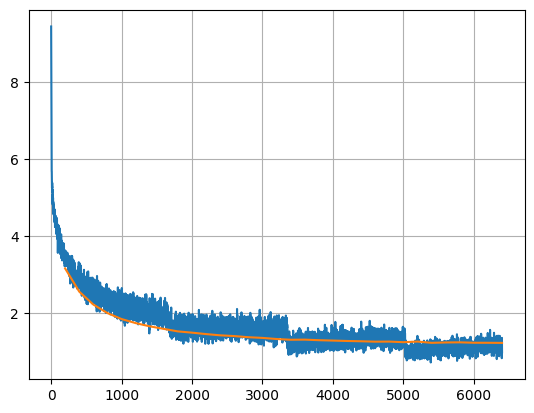

In [ ]:


# 绘制训练集loss曲线（x轴为step步数，y轴为损失值），有助于观察训练过程的收敛情况
plt.plot(
    [i["step"] for i in record["train"]],   # 训练集记录中每一步(step)
    [i["loss"] for i in record["train"]],   # 训练集每一步的损失(loss)
    label="train"                           # 曲线标签
)

# 绘制验证集loss曲线（便于对比训练集与验证集表现，判断过拟合等问题）
plt.plot(
    [i["step"] for i in record["val"]],     # 验证集记录的步数
    [i["loss"] for i in record["val"]],     # 验证集损失
    label="val"                             # 曲线标签
)

plt.grid()      # 显示网格线，提高可读性
plt.show()      # 展示图像

## 推理

- 接下来进行翻译推理，并作出注意力的热度图

In [41]:
!ls checkpoints/translate-seq2seq

best.ckpt


In [ ]:
# 加载模型权重（load checkpoints），可以用于部署上线或本地测试
model = Sequence2Sequence(len(src_word2idx), len(trg_word2idx))  # 新建一个与训练时结构一致的模型对象
model.load_state_dict(torch.load(f"best.ckpt", weights_only=True, map_location="cpu"))  # 加载保存在文件中的最佳模型权重

class Translator:
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        self.model = model
        self.model.eval()  # 切换到评估/推理（验证）模式，关闭 Dropout、BatchNorm 等训练特有行为
        self.src_tokenizer = src_tokenizer  # 源语言分词器
        self.trg_tokenizer = trg_tokenizer  # 目标语言分词器

    def draw_attention_map(self, scores, src_words_list, trg_words_list):
        """
        绘制注意力热力图，用于可视化源语言与翻译过程中的目标语言之间的关联关系。

        Args:
            - scores (numpy.ndarray): 注意力分数矩阵，shape = [源序列长度, 目标序列长度]
            - src_words_list (List[str]): 源句子词序列
            - trg_words_list (List[str]): 目标句子词序列
        """
        plt.matshow(scores.T, cmap='viridis')  # 显示注意力分数值的热图（矩阵转置以确保 X 轴和 Y 轴的方向与词对应）
        ax = plt.gca()  # 获取当前坐标轴对象

        # 在每个格子里标注分数的小数值，便于精细观察各单词间的注意力
        for i in range(scores.shape[0]):  # 遍历所有源位置（横轴）
            for j in range(scores.shape[1]):  # 遍历所有目标位置（纵轴）
                ax.text(j, i, f'{scores[i, j]:.2f}', ha='center', va='center', color='k')  # 分数格式化到小数点后2位

        plt.xticks(range(scores.shape[0]), src_words_list)  # X轴标记为源语言单词
        plt.yticks(range(scores.shape[1]), trg_words_list)  # Y轴标记为目标语言单词
        plt.show()

    def __call__(self, sentence):
        # 1. 首先对原始输入句子进行预处理（如标点处理、小写等：视 preprocess_sentence 的具体实现而定）
        sentence = preprocess_sentence(sentence)

        # 2. 使用源语言分词器进行分词、编码为索引ID序列，并进行必要的padding、添加BOS/EOS，并返回 mask
        encoder_input, attn_mask = self.src_tokenizer.encode(
            [sentence.split()],        # 输入为分好词的句子列表（只包含一个句子）
            padding_first=True,        # padding放在前面
            add_bos=True,              # 添加 <bos> 开头
            add_eos=True,              # 添加 <eos> 结尾
            return_mask=True,          # 返回pad mask，用以注意力或编码检测
        )
        # 3. 转化为tensor；long/int64类型以用于Embedding等模型层
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64)

        # 4. 调用模型的 infer 推理接口，返回预测出来的目标语言的token索引序列，以及注意力分数
        preds, scores = model.infer(encoder_input=encoder_input, attn_mask=attn_mask)

        # 5. 将预测ID序列转回目标语言自然文字（split=True每个token独立成单词，remove_eos=False保留结尾<EOS>用于界定终止）
        trg_sentence = self.trg_tokenizer.decode([preds], split=True, remove_eos=False)[0]

        # 6. 为了绘制注意力图，将输入的token id的序列再通过tokenizer decode回原始的词字符串
        src_decoded = self.src_tokenizer.decode(
            encoder_input.tolist(),
            split=True,       # 返回每个token分词
            remove_bos=False, # 不去除开始符号
            remove_eos=False  # 不去除结束符号
        )[0]

        # 7. 绘制注意力热力图（不同目标词对源词的注意分布可视化）
        self.draw_attention_map(
            scores.squeeze(0).numpy(),  # 移除batch维度，转成numpy数组
            src_decoded,                # 注意力图的横轴：源句子分词
            trg_sentence                # 注意力图的纵轴：预测目标句子分词
        )
        # 8. 返回最终的预测翻译句子（通常去掉最后的EOS token）
        return " ".join(trg_sentence[:-1])


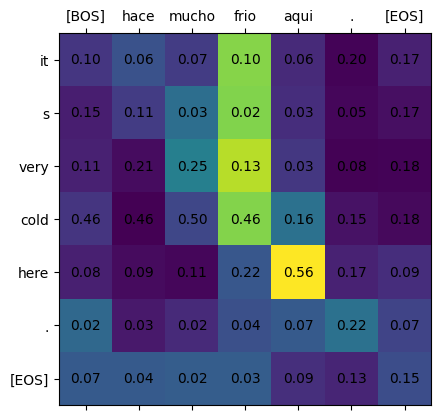

'it s very cold here .'

In [43]:
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)
translator('hace mucho frio aqui .')

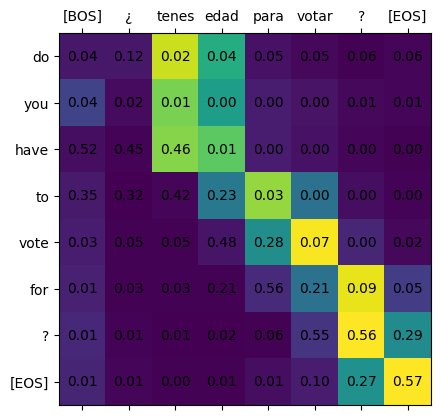

'do you have to vote for ?'

In [44]:
translator(u'¿Tenés edad para votar?')

In [45]:
# 初始化Seq2Seq模型对象（输入和输出词表的大小分别为源和目标词表大小）
model = Sequence2Sequence(len(src_word2idx), len(trg_word2idx))
# 从保存的模型文件加载最佳训练权重至模型
model.load_state_dict(torch.load(f"./checkpoints/translate-seq2seq/best.ckpt", map_location="cpu"))

class Translator:
    """
    用于序列到序列神经机器翻译模型的推理/翻译器类。
    支持调用方法(即 translator(sentence))直接完成句子翻译。
    """
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        """
        :param model: 已训练好的 Seq2Seq 神经网络模型
        :param src_tokenizer: 源语言分词器
        :param trg_tokenizer: 目标语言分词器
        """
        self.model = model
        self.model.eval() # 进入评估/推理模式，禁用dropout等，仅做前向传播
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

    def __call__(self, sentence):
        """
        实现 __call__，可直接用 translator(...) 方式取得翻译结果
        :param sentence: 输入要翻译的源语言句子（字符串）
        :return: 翻译好的目标语言自然句文本
        """
        # 1. 句子预处理（通常包括小写化、标点标准化、清理等）
        sentence = preprocess_sentence(sentence) # 预处理句子，如标点符号处理等

        # 2. 用分词器分词，并编码为id，添加padding、BOS/EOS等，生成输入张量及对应attention mask
        encoder_input, attn_mask = self.src_tokenizer.encode(
            [sentence.split()],       # 输入需要分词后的句子列表，此处只含1句
            padding_first=True,       # padding添加在序列前部
            add_bos=True,             # 添加<bos>符号
            add_eos=True,             # 添加<eos>符号
            return_mask=True,         # 返回对应的padding mask
        )
        # 3. 转为PyTorch张量（int64类型，适配后续Embedding/模型输入等）
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64)

        # 4. 用模型的infer接口进行推理，得到预测的目标语言token id序列及attention分数等
        preds, scores = model.infer(encoder_input=encoder_input, attn_mask=attn_mask)

        # 5. 把预测id序列转回实际目标句子的分词文本（保留<eos>作为结尾标识）
        trg_sentence = self.trg_tokenizer.decode([preds], split=True, remove_eos=False)[0]

        # 6. 返回翻译结果字符串，通常去除结尾的<EOS>符号后拼接输出
        return " ".join(trg_sentence[:-1])

from nltk.translate.bleu_score import sentence_bleu

def evaluate_bleu_on_test_set(test_data, translator):
    """
    在测试集上评估平均BLEU分数
    :param test_data: 测试集数据（列表，每个元素为 ：(源语言原句, 目标语言参考译文) ），即[(src_sentence, ref_translations), ...]
    :param translator: 翻译器对象（Translator实例）
    :return: test set的平均BLEU分数
    """
    total_bleu = 0.0  # 累加每个样本的BLEU分
    num_samples = len(test_data)  # 测试集样本数

    # 遍历测试集中的每个句子（包含源句和参考译文）
    for src_sentence, ref_translations in test_data:
        # 利用Translator得到候选翻译
        candidate_translation = translator(src_sentence)

        # 计算该句的BLEU分（此处对所有单句采用1-gram，即unigram精度；可更改weights参数以兼容长ngram）
        bleu_score = sentence_bleu([ref_translations.split()],     # 参考译文(分词list)的list
                                   candidate_translation.split(),  # 预测译文(分词list)
                                   weights=(1, 0, 0, 0))           # 仅计unigram精度
        total_bleu += bleu_score     # 累加

        # 可选: 打印每个句子的bleu细节信息
        # print(f"Source: {src_sentence}")
        # print(f"Reference: {ref_translations}")
        # print(f"Candidate: {candidate_translation}")
        # print(f"BLEU: {bleu_score:.4f}")
        # print("-" * 50)
        # i += 1
        # if i > 10: break # 如仅调试，限制前10

    # 计算平均BLEU分
    avg_bleu = total_bleu / num_samples if num_samples > 0 else 0.0
    return avg_bleu

# 实例化translate对象，cpu模式（如需gpu推理，可换成.cuda()）
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)

# 计算并返回test_ds的平均BLEU分数
evaluate_bleu_on_test_set(test_ds, translator)

/root/miniconda3/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/root/miniconda3/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/root/miniconda3/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()

0.705207455133632